In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [23]:
#1A

def relative_perm(sw, swi, sor, nw, no, kwo, koo):
    
    S = (sw - swi) / (1 - swi - sor)

    if S <= 0:
        kw = 0
    elif S >= 1:
        kw = kwo
    else:
        kw = kwo * S ** nw

    if S <= 0:
        ko = koo
    elif S >= 1:
        ko = 0
    else:
        ko = koo * (1 - S) ** no
    
    return kw, ko

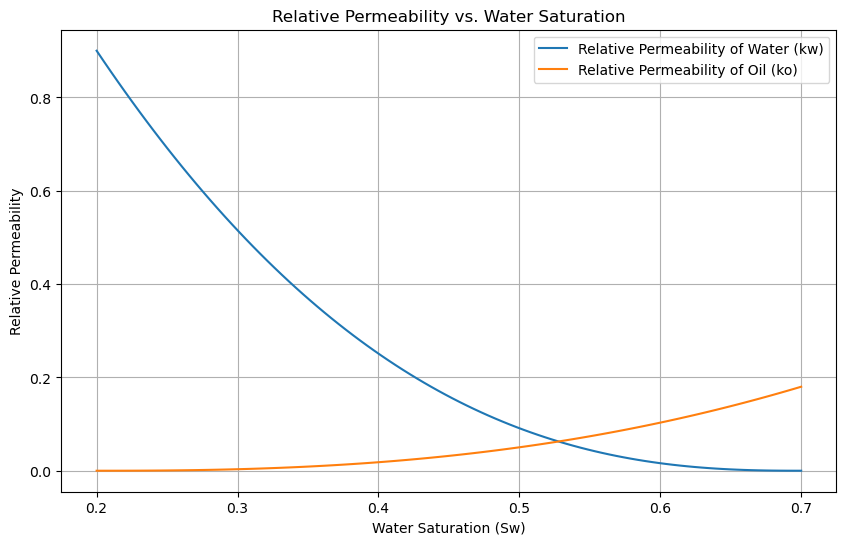

In [27]:
#1B

import numpy as np
import matplotlib.pyplot as plt

def relative_perm(sw, swi, sor, nw, no, kwo, koo):

    S = (sw - swi) / (1 - swi - sor)

    S = max(0, min(S, 1))

    if S <= 0:
        kw = kwo 
    elif S >= 1:
        kw = 0 
    else:
        kw = kwo * (1 - S) ** nw

    if S <= 0:
        ko = 0   
    elif S >= 1:
        ko = koo 
    else:
        ko = koo * S ** no 
    
    return kw, ko

swi = 0.2 
sor = 0.3 
nw = 2.5 
no = 2.5 
kwo = 0.9 
koo = 0.18 

sw_values = np.linspace(swi, 1 - sor, 100)

kw_values = []
ko_values = []
for sw in sw_values:
    kw, ko = relative_perm(sw, swi, sor, nw, no, kwo, koo)
    kw_values.append(kw)
    ko_values.append(ko)

plt.figure(figsize=(10, 6))
plt.plot(sw_values, kw_values, label='Relative Permeability of Water (kw)')
plt.plot(sw_values, ko_values, label='Relative Permeability of Oil (ko)')
plt.xlabel('Water Saturation (Sw)')
plt.ylabel('Relative Permeability')
plt.title('Relative Permeability vs. Water Saturation')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
#1C

def fractional_flow(sw, swi, sor, nw, no, kwo, koo, mu_w, mu_o, rho_w, rho_o, g, L, theta):

    kw, ko = relative_perm(sw, swi, sor, nw, no, kwo, koo)
    
    lambda_w = kw / mu_w
    lambda_o = ko / mu_o
    
    gravity_term = (rho_w - rho_o) * g * L * np.sin(theta)
    
    fw = lambda_w / (lambda_w + lambda_o + gravity_term)
    
    delta_sw = 1e-6
    sw_perturbed = sw + delta_sw
    
    kw_perturbed, ko_perturbed = relative_perm(sw_perturbed, swi, sor, nw, no, kwo, koo)
    lambda_w_perturbed = kw_perturbed / mu_w
    lambda_o_perturbed = ko_perturbed / mu_o
    
    fw_perturbed = lambda_w_perturbed / (lambda_w_perturbed + lambda_o_perturbed + gravity_term)
    
    dfw_dsw = (fw_perturbed - fw) / delta_sw
    
    return fw, dfw_dsw

C:\Users\jns05\AppData\Local\Temp\ipykernel_23472\2772837348.py:10: RuntimeWarning: invalid value encountered in power
  kro = kro0 * (1 - S)**no  # Oil relative permeability
C:\Users\jns05\AppData\Local\Temp\ipykernel_23472\2772837348.py:20: RuntimeWarning: divide by zero encountered in divide
  fw = 1 / (1 + (kro * mu_w) / (krw * mu_o))


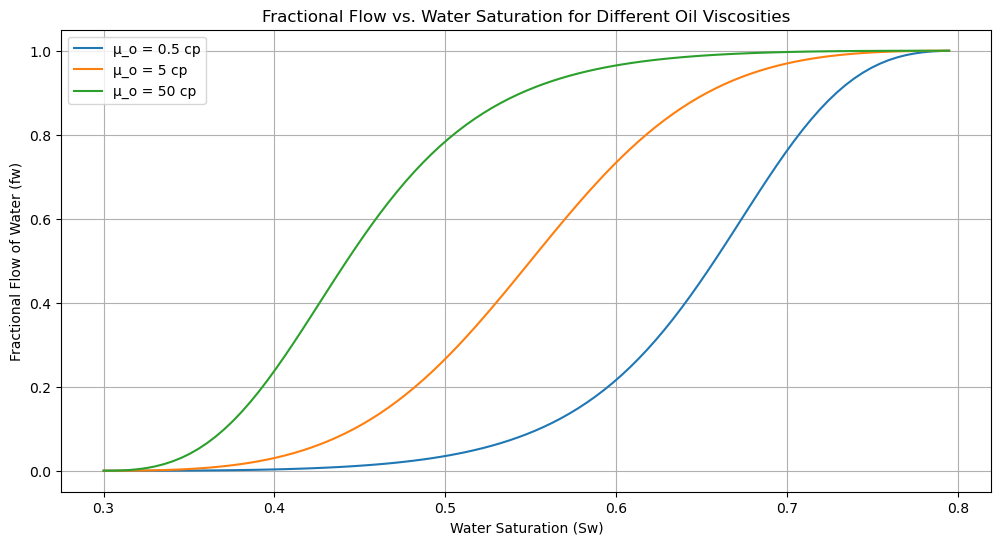

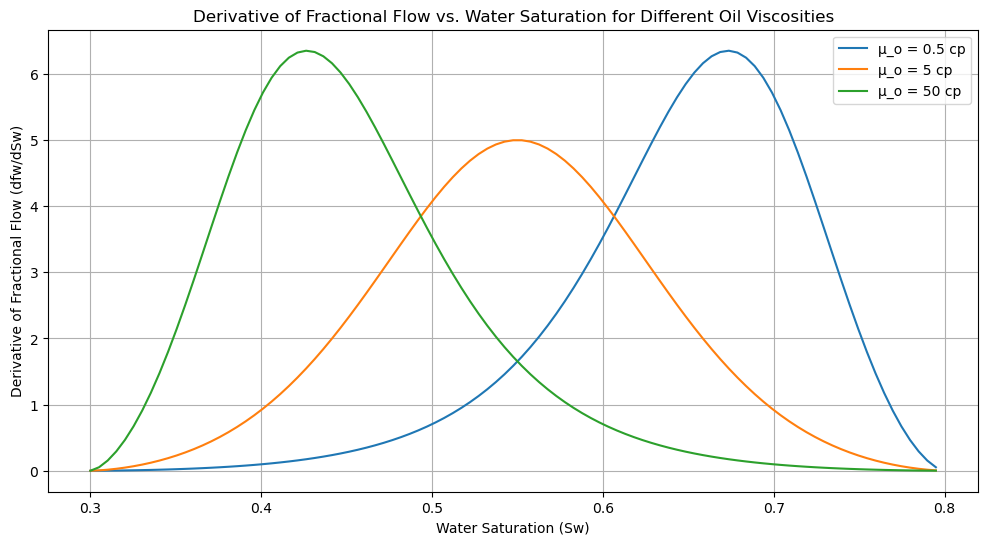

In [29]:
#1D

import numpy as np
import matplotlib.pyplot as plt

def relative_permeability(Sw, Swr, Sor, kro0, krw0, nw, no):

    S = (Sw - Swr) / (1 - Swr - Sor) 
    krw = krw0 * S**nw 
    kro = kro0 * (1 - S)**no
    return kro, krw

def fractional_flow(Sw, Swr, Sor, kro0, krw0, no, nw, mu_o, mu_w, u, k, rho_w, rho_o, alpha):

    kro, krw = relative_permeability(Sw, Swr, Sor, kro0, krw0, nw, no)
    
    fw = 1 / (1 + (kro * mu_w) / (krw * mu_o))
    
    dSw = 1e-6
    Sw2 = Sw + dSw
    kro2, krw2 = relative_permeability(Sw2, Swr, Sor, kro0, krw0, nw, no)
    fw2 = 1 / (1 + (kro2 * mu_w) / (krw2 * mu_o))
    dfw_dSw = (fw2 - fw) / dSw
    
    return fw, dfw_dSw

mu_w = 1.0 
u = 0.01
k = 500
rho_w = 62.4
rho_o = 35
alpha = 0

Swr = 0.3
Sor = 0.2
kro0 = 0.9
krw0 = 0.18
nw = 2.5
no = 2.5

Sw = np.linspace(Swr, 1 - Sor, 100)

mu_o_list = [0.5, 5, 50]

plt.figure(figsize=(12, 6))
for mu_o in mu_o_list:
    fw, _ = fractional_flow(Sw, Swr, Sor, kro0, krw0, no, nw, mu_o, mu_w, u, k, rho_w, rho_o, alpha)
    plt.plot(Sw, fw, label=f'μ_o = {mu_o} cp')

plt.xlabel('Water Saturation (Sw)')
plt.ylabel('Fractional Flow of Water (fw)')
plt.title('Fractional Flow vs. Water Saturation for Different Oil Viscosities')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
for mu_o in mu_o_list:
    _, dfw_dSw = fractional_flow(Sw, Swr, Sor, kro0, krw0, no, nw, mu_o, mu_w, u, k, rho_w, rho_o, alpha)
    plt.plot(Sw, dfw_dSw, label=f'μ_o = {mu_o} cp')

plt.xlabel('Water Saturation (Sw)')
plt.ylabel('Derivative of Fractional Flow (dfw/dSw)')
plt.title('Derivative of Fractional Flow vs. Water Saturation for Different Oil Viscosities')
plt.legend()
plt.grid(True)
plt.show()

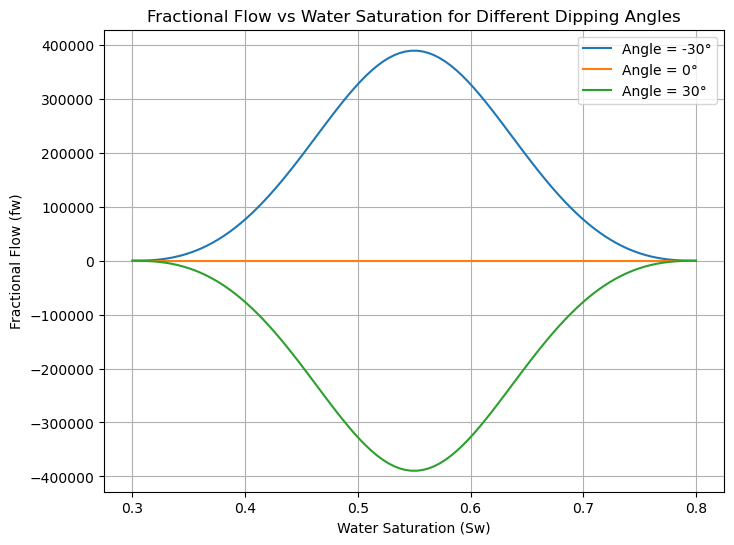

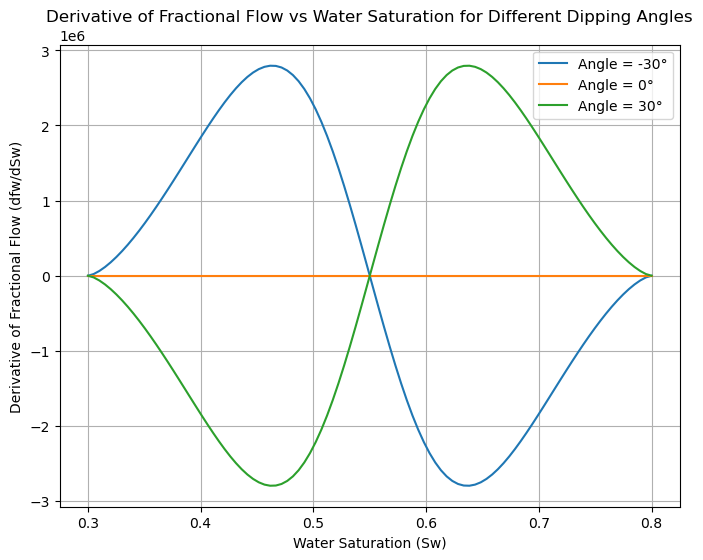

In [60]:
import numpy as np
import matplotlib.pyplot as plt

def relative_permeability(Sw, Swr, Sor, kro0, krw0, nw, no):

    S = (Sw - Swr) / (1 - Swr - Sor)
    S = max(0, min(S, 1))
    krw = krw0 * S**nw 
    kro = kro0 * (1 - S)**no 
    return kro, krw

def fractional_flow1(Sw, a, mu_o=5, mu_w=1, u=0.01, k=500, rho_w=62.4, rho_o=35):

    Swr = 0.3
    Sor = 0.2
    kro0 = 0.9 
    krw0 = 0.18 
    nw = 2.5
    no = 2.5

    kro, krw = relative_permeability(Sw, Swr, Sor, kro0, krw0, nw, no)
    
    lambda_w = krw / mu_w
    lambda_o = kro / mu_o
    
    Ng = (k * (rho_w - rho_o) * 32.174 * np.sin(np.radians(a))) / (u * mu_o)
    
    if lambda_w == 0:
        fw = 0 
    else:
        S = (Sw - Swr) / (1 - Swr - Sor)
        S = max(0, min(S, 1))
        fw = (1 - Ng * (1 - S)**no) / (1 + (lambda_o / lambda_w))
    
    return fw, Ng

def fractional_flow_derivative1(Sw, a, mu_o=5, mu_w=1, u=0.01, k=500, rho_w=62.4, rho_o=35):

    dSw = 1e-6
    fw1, Ng = fractional_flow1(Sw, a, mu_o, mu_w, u, k, rho_w, rho_o)
    fw2, Ng = fractional_flow1(Sw + dSw, a, mu_o, mu_w, u, k, rho_w, rho_o)
    dfw_dSw = (fw2 - fw1) / dSw
    return dfw_dSw

def plot_fractional_flow_angle():

    Sw_values = np.linspace(0.3, 0.8, 100)
    a_list = [-30, 0, 30]

    plt.figure(figsize=(8, 6))
    for a in a_list:
        fw_values = [fractional_flow1(Sw, a)[0] for Sw in Sw_values]
        plt.plot(Sw_values, fw_values, label=f'Angle = {a}°')

    plt.xlabel('Water Saturation (Sw)')
    plt.ylabel('Fractional Flow (fw)')
    plt.legend()
    plt.title('Fractional Flow vs Water Saturation for Different Dipping Angles')
    plt.grid()
    plt.show()

    plt.figure(figsize=(8, 6))
    for a in a_list:
        dfw_values = [fractional_flow_derivative1(Sw, a) for Sw in Sw_values]
        plt.plot(Sw_values, dfw_values, label=f'Angle = {a}°')

    plt.xlabel('Water Saturation (Sw)')
    plt.ylabel('Derivative of Fractional Flow (dfw/dSw)')
    plt.legend()
    plt.title('Derivative of Fractional Flow vs Water Saturation for Different Dipping Angles')
    plt.grid()
    plt.show()

plot_fractional_flow_angle()